In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [3]:
import os
os.getcwd()


'C:\\Users\\duvva'

In [4]:
import os
os.listdir()

['.anaconda',
 '.cisco_mds9000',
 '.conda',
 '.continuum',
 '.eclipse',
 '.idlerc',
 '.InstallAnywhere',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '.p2',
 '.vscode',
 '.vscode-shared',
 '1.R',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 'Desktop',
 'Documents',
 'Downloads',
 'eclipse',
 'eclipse-workspace',
 'Favorites',
 'first.py',
 'IntelGraphicsProfiles',
 'Links',
 'Local Settings',
 'Microsoft',
 'Music',
 'My Documents',
 'NetHood',
 'New folder',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{da9debd5-cd57-11ec-b66f-9bda68a1f654}.TM.blf',
 'NTUSER.DAT{da9debd5-cd57-11ec-b66f-9bda68a1f654}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{da9debd5-cd57-11ec-b66f-9bda68a1f654}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'Pictures',
 'PrintHood',
 'Recent',
 'sagar.py',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'Templates',
 'Untitled.ipynb',
 'Videos']

In [5]:
japan = pd.read_excel("JPN Data.xlsx")
india = pd.read_excel("IN_Data.xlsx")


In [7]:
japan.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,PURCHASE
0,00001Q15YJ,50,M,445344.000000,439,0
1,00003I71CQ,35,M,107634.000000,283,0
2,00003N47FS,59,F,502786.666667,390,1
3,00005H41DE,43,M,585664.000000,475,0
4,00007E17UM,39,F,705722.666667,497,1


In [8]:
india.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT
0,20710B05XL,54,M,1425390,2018-04-20
1,89602T51HX,47,M,1678954,2018-06-08
2,70190Z52IP,60,M,931624,2017-07-31
3,25623V15MU,55,F,1106320,2017-07-31
4,36230I68CE,32,F,748465,2019-01-27


In [9]:
print("Japan Dataset Shape:", japan.shape)
print("India Dataset Shape:", india.shape)

Japan Dataset Shape: (40000, 6)
India Dataset Shape: (70000, 5)


In [10]:
japan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          40000 non-null  object 
 1   CURR_AGE    40000 non-null  int64  
 2   GENDER      40000 non-null  object 
 3   ANN_INCOME  40000 non-null  float64
 4   AGE_CAR     40000 non-null  int64  
 5   PURCHASE    40000 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 1.8+ MB


In [11]:
india.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ID          70000 non-null  object        
 1   CURR_AGE    70000 non-null  int64         
 2   GENDER      70000 non-null  object        
 3   ANN_INCOME  70000 non-null  int64         
 4   DT_MAINT    70000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 2.7+ MB


In [12]:
japan.isnull().sum()

ID            0
CURR_AGE      0
GENDER        0
ANN_INCOME    0
AGE_CAR       0
PURCHASE      0
dtype: int64

In [13]:
india.isnull().sum()

ID            0
CURR_AGE      0
GENDER        0
ANN_INCOME    0
DT_MAINT      0
dtype: int64

In [14]:
print("Japan duplicates:", japan.duplicated().sum())
print("India duplicates:", india.duplicated().sum())

Japan duplicates: 0
India duplicates: 0


In [15]:
japan.drop("ID", axis=1, inplace=True)

In [16]:
japan.head()


,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,PURCHASE
0,50,M,445344.000000,439,0
1,35,M,107634.000000,283,0
2,59,F,502786.666667,390,1
3,43,M,585664.000000,475,0
4,39,F,705722.666667,497,1


In [17]:
japan["PURCHASE"].value_counts()

PURCHASE
1    23031
0    16969
Name: count, dtype: int64

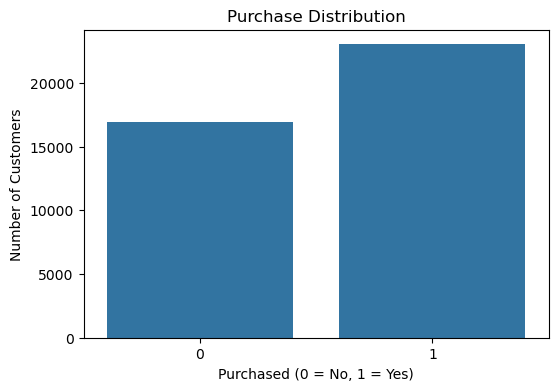

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="PURCHASE", data=japan)
plt.title("Purchase Distribution")
plt.xlabel("Purchased (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

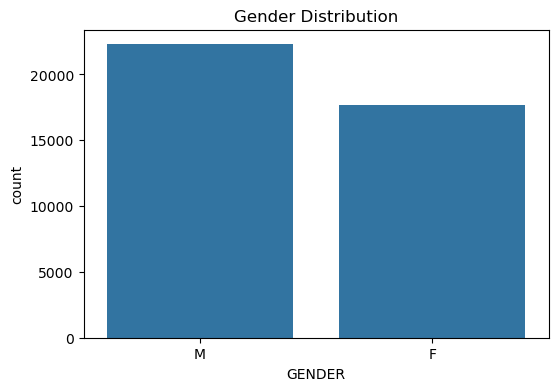

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x="GENDER", data=japan)
plt.title("Gender Distribution")
plt.show()

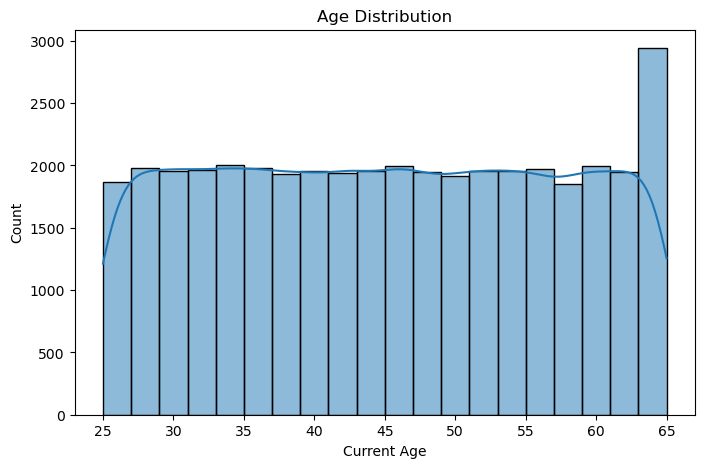

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(japan["CURR_AGE"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Current Age")
plt.show()

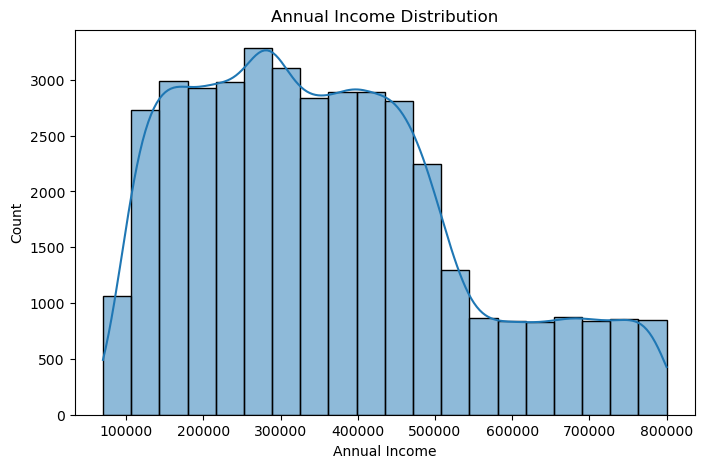

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(japan["ANN_INCOME"], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.show()

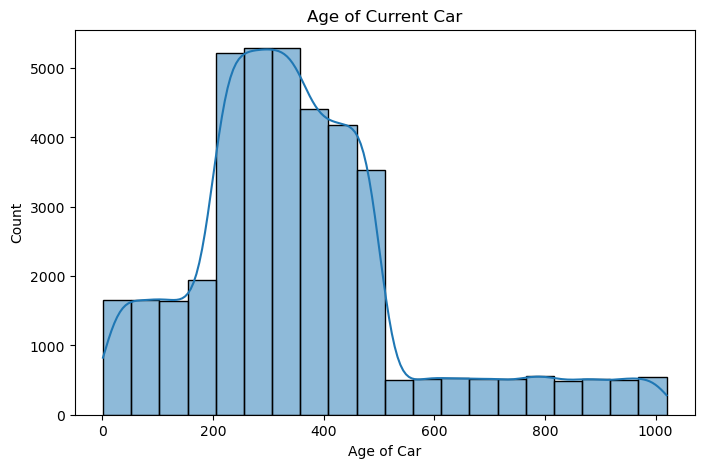

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(japan["AGE_CAR"], bins=20, kde=True)
plt.title("Age of Current Car")
plt.xlabel("Age of Car")
plt.show()

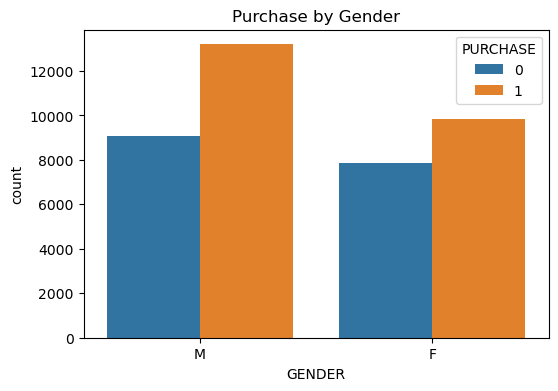

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x="GENDER", hue="PURCHASE", data=japan)
plt.title("Purchase by Gender")
plt.show()

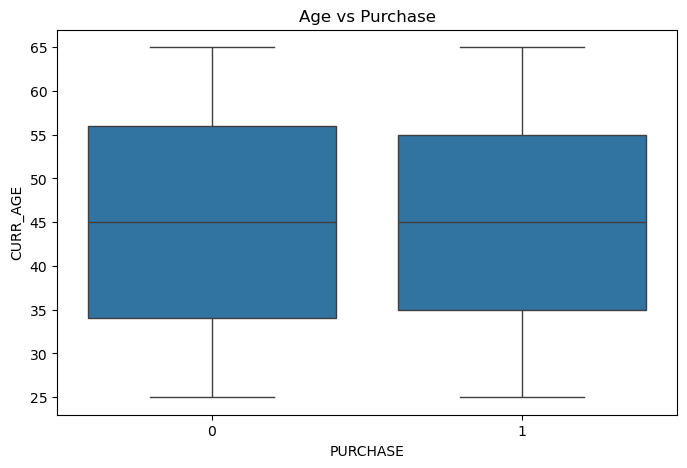

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x="PURCHASE", y="CURR_AGE", data=japan)
plt.title("Age vs Purchase")
plt.show()

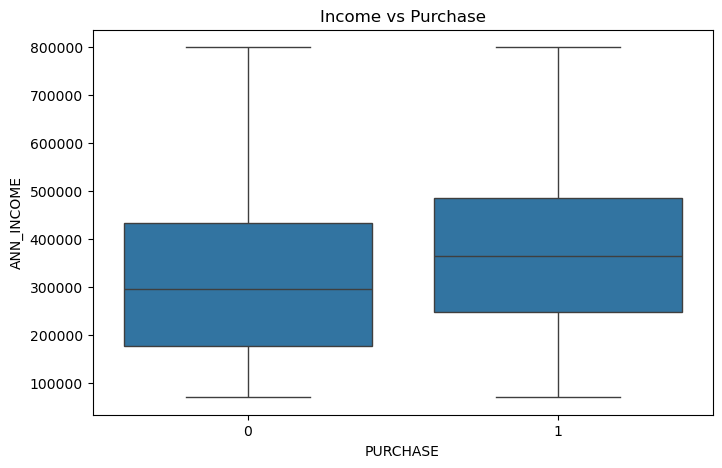

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x="PURCHASE", y="ANN_INCOME", data=japan)
plt.title("Income vs Purchase")
plt.show()

In [26]:
japan["GENDER"] = japan["GENDER"].map({"M":1, "F":0})

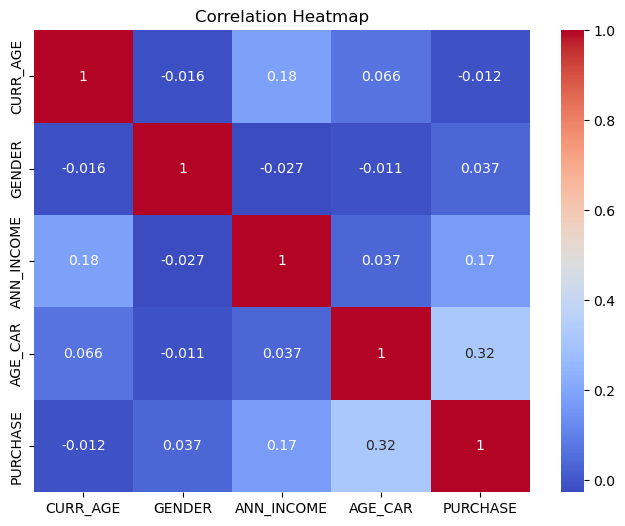

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(japan.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [28]:
japan["GENDER"] = japan["GENDER"].map({"M":1, "F":0})

In [29]:
japan.head()

,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,PURCHASE
0,50,NaN,445344.000000,439,0
1,35,NaN,107634.000000,283,0
2,59,NaN,502786.666667,390,1
3,43,NaN,585664.000000,475,0
4,39,NaN,705722.666667,497,1


In [30]:
import pandas as pd

japan = pd.read_excel("JPN Data.xlsx")

In [31]:
japan.drop("ID", axis=1, inplace=True)

In [32]:
print(japan["GENDER"].unique())

['M' 'F']


In [34]:
japan["GENDER"] = japan["GENDER"].map({"M": 1, "F": 0})

In [35]:
print(japan["GENDER"].head())
print(japan["GENDER"].unique())

0    1
1    1
2    0
3    1
4    0
Name: GENDER, dtype: int64
[1 0]


In [36]:
X = japan.drop("PURCHASE", axis=1)
y = japan["PURCHASE"]

In [37]:
print(X.head())
print(y.head())

   CURR_AGE  GENDER     ANN_INCOME  AGE_CAR
0        50       1  445344.000000      439
1        35       1  107634.000000      283
2        59       0  502786.666667      390
3        43       1  585664.000000      475
4        39       0  705722.666667      497
0    0
1    0
2    1
3    0
4    1
Name: PURCHASE, dtype: int64


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [39]:
print(X_train.shape)
print(X_test.shape)

(32000, 4)
(8000, 4)


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [42]:
y_pred = model.predict(X_test)

In [43]:
y_prob = model.predict_proba(X_test)[:, 1]

In [44]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.684125


In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1833 1516]
 [1011 3640]]


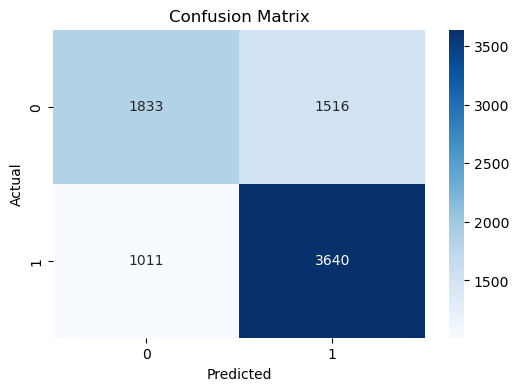

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.55      0.59      3349
           1       0.71      0.78      0.74      4651

    accuracy                           0.68      8000
   macro avg       0.68      0.66      0.67      8000
weighted avg       0.68      0.68      0.68      8000



In [48]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.736959960514115


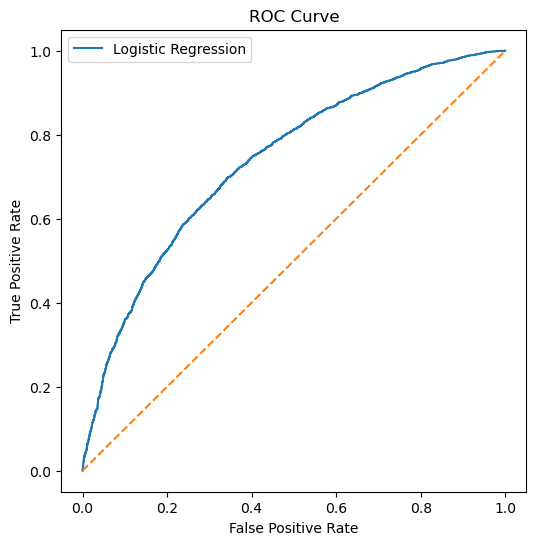

In [49]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [50]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef = coef.sort_values(by="Coefficient", ascending=False)
print(coef)

      Feature  Coefficient
3     AGE_CAR     0.846388
2  ANN_INCOME     0.403873
1      GENDER     0.108943
0    CURR_AGE    -0.126194


In [51]:
india.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT
0,20710B05XL,54,M,1425390,2018-04-20
1,89602T51HX,47,M,1678954,2018-06-08
2,70190Z52IP,60,M,931624,2017-07-31
3,25623V15MU,55,F,1106320,2017-07-31
4,36230I68CE,32,F,748465,2019-01-27


In [52]:
india.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ID          70000 non-null  object        
 1   CURR_AGE    70000 non-null  int64         
 2   GENDER      70000 non-null  object        
 3   ANN_INCOME  70000 non-null  int64         
 4   DT_MAINT    70000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 2.7+ MB


In [53]:
india["DT_MAINT"].head(10)

0   2018-04-20
1   2018-06-08
2   2017-07-31
3   2017-07-31
4   2019-01-27
5   2018-11-24
6   2018-09-22
7   2018-04-05
8   2018-01-02
9   2018-04-23
Name: DT_MAINT, dtype: datetime64[ns]

In [54]:
india["DT_MAINT"].describe()

count                            70000
mean     2018-06-28 16:10:28.662856960
min                2016-09-14 00:00:00
25%                2018-03-15 00:00:00
50%                2018-07-26 00:00:00
75%                2018-12-24 00:00:00
max                2019-06-30 00:00:00
Name: DT_MAINT, dtype: object

In [55]:
india["DT_MAINT"] = pd.to_datetime(india["DT_MAINT"])

In [56]:
reference_date = india["DT_MAINT"].max()

india["AGE_CAR"] = (reference_date - india["DT_MAINT"]).dt.days

In [57]:
india["GENDER"] = india["GENDER"].map({"M":1, "F":0})

In [58]:
india_features = india[["CURR_AGE", "GENDER", "ANN_INCOME", "AGE_CAR"]]

In [59]:
india_scaled = scaler.transform(india_features)

In [60]:
india_pred = model.predict(india_scaled)

In [61]:
india["PURCHASE_PRED"] = india_pred

In [62]:
buyers = india["PURCHASE_PRED"].sum()

print("Potential Buyers:", buyers)

Potential Buyers: 67231


In [6]:
import pandas as pd

japan = pd.read_excel("JPN Data.xlsx")

In [7]:
japan.drop("ID", axis=1, inplace=True)

In [8]:
japan["GENDER"] = japan["GENDER"].map({"M": 1, "F": 0})

In [9]:
japan_tableau = japan.copy()

japan_tableau["GENDER"] = japan_tableau["GENDER"].map({1: "Male", 0: "Female"})

japan_tableau.to_excel("Japan_Final.xlsx", index=False)

In [11]:
import pandas as pd

india = pd.read_excel("IN_Data.xlsx")

In [14]:
X = japan.drop("PURCHASE", axis=1)
y = japan["PURCHASE"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
india.to_excel("India_Final.xlsx", index=False)